# Spam Mail Detector

## Objective
The objective of this project is to classify SMS messages as Spam or Ham using Machine Learning and Natural Language Processing techniques.

## Dataset
SMS Spam Collection Dataset

## Algorithm Used
Logistic Regression

## Feature Extraction
TF-IDF Vectorizer

##IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


## STEP 1: Load the Dataset

This step involves loading the 'spam.csv' file into a pandas DataFrame, which is the foundation of our spam mail detection project.

In [4]:
df = pd.read_csv("spam.csv", encoding='latin1')

## STEP 2: Initial Data Inspection - `df.head()`

We display the first few rows of the DataFrame to get a quick overview of its structure, column names, and the type of data it contains.

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## STEP 3: Check Data Dimensions - `df.shape`

This step helps us understand the size of our dataset by showing the total number of rows (entries) and columns (features).

In [6]:
df.shape

(5572, 5)

## STEP 4: Get Data Information - `df.info()`

We use `df.info()` to get a concise summary of the DataFrame, including the data types of each column, the number of non-null values, and memory usage. This is crucial for identifying potential data quality issues.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


## STEP 5: Descriptive Statistics - `df.describe()`

This step generates descriptive statistics that summarize the central tendency, dispersion, and shape of the dataset's distribution, excluding `NaN` values. For object-type columns, it provides count, unique values, top occurring value, and its frequency.

In [8]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


##STEP 6: Check Missing Values

In [9]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


##STEP 7: Duplicate Values Remove

In [10]:
df.drop_duplicates(inplace=True)

##STEP 8: Labels Convert

In [11]:
df.rename(columns={'v1':'target', 'v2':'text'},inplace=True)
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df['target'] = df['target'].map({'ham':0,'spam':1})
display(df.head())

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## STEP 9: Text Preprocessing

### Lowercasing

In [12]:
df['text'] = df['text'].str.lower()
display(df.head())

,target,text
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


### Remove Punctuation and Special Characters (Optional for some TF-IDF settings, but good for cleaner text)

While TF-IDF can handle many characters, cleaning them improves tokenization quality. We'll also implicitly handle tokenization when we apply the TF-IDF vectorizer.


In [13]:
import re

def remove_punctuations(text):
    return re.sub(r'[^a-z0-9\s]', '', text)

df['text'] = df['text'].apply(remove_punctuations)
display(df.head())

,target,text
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...


## STEP 10: Feature Extraction (TF-IDF)

We will use `TfidfVectorizer` to convert our text data into numerical feature vectors. TF-IDF (Term Frequency-Inverse Document Frequency) reflects the importance of a word in a document relative to a collection of documents. It also handles tokenization and can remove stopwords automatically.

In [14]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = tfidf_vectorizer.fit_transform(df['text'])
y = df['target']

print(f"Shape of TF-IDF feature matrix: {X.shape}")

Shape of TF-IDF feature matrix: (5169, 5000)


## STEP 11: Split Data into Training and Testing Sets

We will split our dataset into an 80/20 ratio for training and testing, respectively. This allows us to train the model on one portion of the data and evaluate its performance on unseen data.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4135, 5000)
X_test shape: (1034, 5000)
y_train shape: (4135,)
y_test shape: (1034,)


## STEP 12: Model Training (Logistic Regression)

We will train a Logistic Regression model, a simple yet effective algorithm for binary classification tasks like spam detection.

In [16]:
logistic_model = LogisticRegression(solver='liblinear', random_state=42)
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## STEP 13: Model Evaluation

We will evaluate the trained model using several metrics: accuracy, a confusion matrix, and a classification report (which includes precision, recall, and F1-score).

In [17]:
y_pred = logistic_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual Ham', 'Actual Spam'], columns=['Predicted Ham', 'Predicted Spam']))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9458

Confusion Matrix:


,Predicted Ham,Predicted Spam
Actual Ham,902,1
Actual Spam,55,76



Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       903
           1       0.99      0.58      0.73       131

    accuracy                           0.95      1034
   macro avg       0.96      0.79      0.85      1034
weighted avg       0.95      0.95      0.94      1034



In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       903
           1       0.99      0.58      0.73       131

    accuracy                           0.95      1034
   macro avg       0.96      0.79      0.85      1034
weighted avg       0.95      0.95      0.94      1034



In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       903
           1       0.99      0.58      0.73       131

    accuracy                           0.95      1034
   macro avg       0.96      0.79      0.85      1034
weighted avg       0.95      0.95      0.94      1034



In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1 Score:", f1_score(y_test, y_pred, pos_label=1))

Precision: 0.987012987012987
Recall: 0.5801526717557252
F1 Score: 0.7307692307692307


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[902   1]
 [ 55  76]]


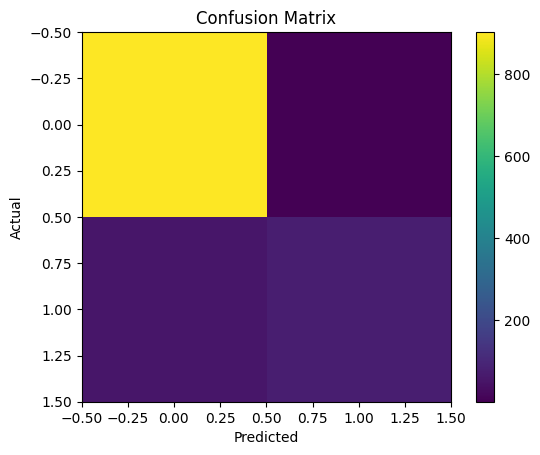

In [25]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Task
The main goal of this task is to build a spam detection model using Logistic Regression. The process involves loading the dataset, performing initial data inspection, cleaning the data by handling missing values and duplicates, preprocessing text data by lowercasing and removing punctuation, extracting features using TF-IDF, splitting the data into training and testing sets, training a Logistic Regression model, and finally evaluating its performance. Additionally, the task includes visualizing the distribution of 'ham' and 'spam' messages in the dataset.

## Step 14:Visualize Target Distribution

### Subtask:
Generate a bar chart to visualize the distribution of 'ham' and 'spam' messages in the dataset.


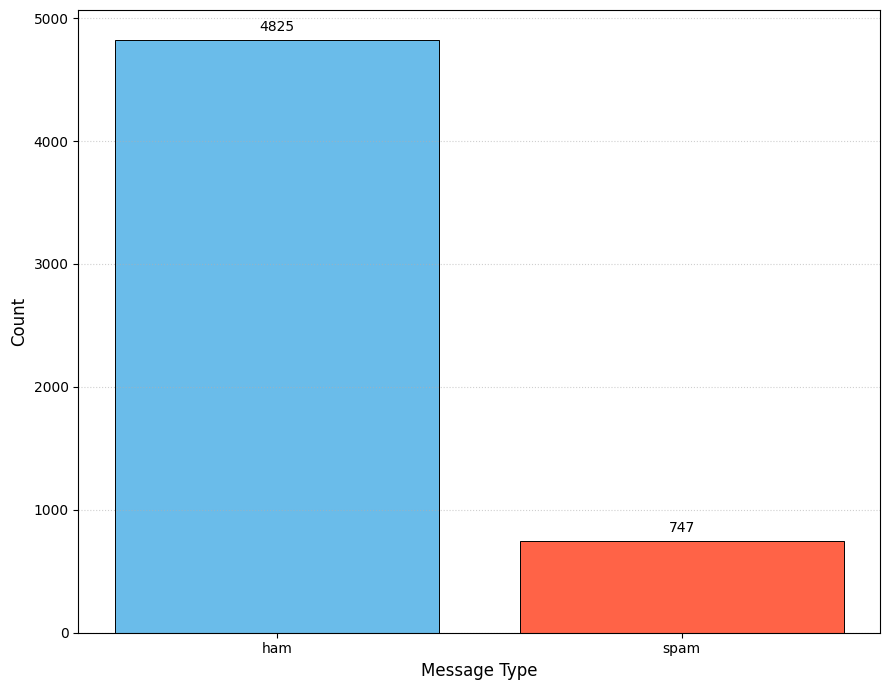

In [ ]:
import matplotlib.pyplot as plt

target_distribution = df['target'].value_counts()
target_distribution.index = target_distribution.index.map({0: 'ham', 1: 'spam'})

plt.figure(figsize=(9, 7))
bars = plt.bar(target_distribution.index, target_distribution.values, color=['#6ABCEA', '#FF6347'], edgecolor='black', linewidth=0.7)

plt.xlabel('Message Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle=':', alpha=0.6)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, round(yval), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Conclusion

In this project, a Spam Mail Detector was built using Natural Language Processing (NLP) and Logistic Regression. The SMS messages were preprocessed, converted into TF-IDF features, and classified into Spam and Ham categories. The model achieved good performance, demonstrating that machine learning can effectively identify spam messages.